In [1]:
import sys
from pathlib import Path
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict, Counter

warnings.filterwarnings('ignore', category=FutureWarning)

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'validation' else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

from annotator.eval.eval import (
    load_detections_as_moments,
    compute_detection_metrics,
    filter_moments_by_type,
    compute_human_ceiling,
    print_scorecard,
)
from annotator.core.utils import (
    load_ground_truth, load_split_ids, EXAMPLE_CONV_IDS,
    compute_iou, merge_overlapping_ranges,
)

## LM validation — v13 annotator eval

1. **Action type** macro F1 for *scaffolding* and *rigor*
2. **Student outcome** macro F1
3. **Effectiveness IAA** — Krippendorff's α at the ±0.5 consensus threshold, all units (≥1 annotator)

Source: `results/annotator/v13/eval_annotations*.json`. 

In [30]:
import glob

EVAL_DIR = REPO_ROOT / "results" / "annotator" / "v13"
THRESHOLD = 0.5  # effectiveness IAA consensus threshold ("all units")

PROFILE_ORDER = ["anthropic", "anthropic46", "openai", "gemini_25_pro", "gemini_35_flash"]
SPLIT_ORDER = ["train", "test"]
SPLIT_PALETTE = {"train": "#1f77b4", "test": "#ff7f0e"}


def iaa_at(type_block, threshold):
    """Krippendorff alpha + n_units at a consensus threshold (JSON keys are strings)."""
    byt = type_block.get("iaa_by_threshold", {})
    for k in (str(threshold), f"{threshold:.1f}"):
        if k in byt:
            return byt[k].get("alpha"), byt[k].get("n_units")
    iaa = type_block.get("iaa", {})  # default block is already +/-0.5
    return iaa.get("alpha"), iaa.get("n_units")


rows = []
for path in sorted(glob.glob(str(EVAL_DIR / "eval_annotations*.json"))):
    d = json.load(open(path))
    profile, split = d.get("profile"), d.get("split")
    if profile is None:
        continue  # legacy unsuffixed file -- duplicate of a profile-suffixed run
    scaf = d["by_type"]["scaffolding"]
    ad = scaf.get("action_direction_f1", {})
    alpha, n_units = iaa_at(scaf, THRESHOLD)
    rows.append({
        "profile": profile,
        "split": split,
        "action_dir_scaffolding_f1": ad.get("scaffolding", {}).get("macro_f1"),
        "action_dir_rigor_f1": ad.get("rigor", {}).get("macro_f1"),
        "student_outcome_f1": scaf.get("student_outcome_f1", {}).get("macro_f1"),
        "iaa_alpha": alpha,
        "iaa_n_units": n_units,
        "human_ceiling_alpha": scaf.get("human_ceiling", {}).get("alpha"),
    })

df = pd.DataFrame(rows)
df["profile"] = pd.Categorical(
    df["profile"], categories=[p for p in PROFILE_ORDER if p in set(df["profile"])], ordered=True)
df["split"] = pd.Categorical(df["split"], categories=SPLIT_ORDER, ordered=True)
df = df.sort_values(["profile", "split"]).reset_index(drop=True)

# Combined profile x split label -- one bar per run. Profiles without a train
# run simply have no train bar (no empty grouped-bar slot).
df["run"] = df["profile"].astype(str) + " / " + df["split"].astype(str)

sns.set_style("whitegrid")


def bar_by_run(ax, col, lim=(0, 1)):
    """One horizontal bar per run, colored by split, with value labels.

    Horizontal so the profile/split labels get full width instead of being
    squished along the x-axis. First run sits at the top.
    """
    sub = df.dropna(subset=[col])
    bars = ax.barh(sub["run"], sub[col], color=[SPLIT_PALETTE[s] for s in sub["split"]])
    ax.bar_label(bars, fmt="%.2f", fontsize=15, padding=2)
    ax.invert_yaxis()  # first run at top
    ax.set_xlim(*lim)
    ax.set_ylabel("")
    ax.tick_params(axis="y", labelsize=15)
    return bars


def split_legend(ax, **kwargs):
    handles = [mpatches.Patch(color=SPLIT_PALETTE[s], label=s) for s in SPLIT_ORDER]
    ax.legend(handles=handles, title="split", **kwargs)


print(f"Loaded {len(df)} runs from {EVAL_DIR}")
df

Loaded 7 runs from /Users/lucyli/Documents/Projects/ai2-synthetic-annotations/results/annotator/v13


,profile,split,action_dir_scaffolding_f1,action_dir_rigor_f1,student_outcome_f1,iaa_alpha,iaa_n_units,human_ceiling_alpha,run
0,anthropic,train,0.9310,0.6537,0.8240,0.4449,866,0.1848,anthropic / train
1,anthropic,test,0.9338,0.6349,0.8175,0.4389,670,0.2403,anthropic / test
2,anthropic46,train,0.9335,0.6255,0.8195,0.4533,866,0.1848,anthropic46 / train
3,anthropic46,test,0.9440,0.6157,0.7905,0.4016,670,0.2403,anthropic46 / test
4,openai,test,0.8968,0.5958,0.7734,0.3701,670,0.2403,openai / test
5,gemini_25_pro,test,0.9494,0.5517,0.7649,0.3809,670,0.2403,gemini_25_pro / test
6,gemini_35_flash,test,0.9388,0.6139,0.7733,0.3952,670,0.2403,gemini_35_flash / test


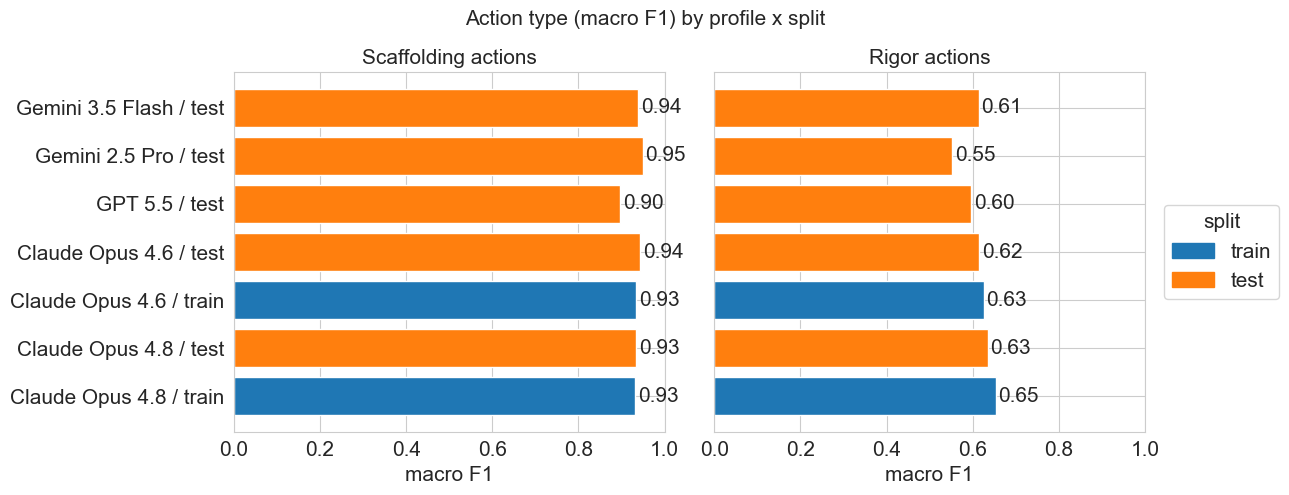

In [45]:
model_map = {
    'anthropic': 'Claude Opus 4.8',
    'anthropic46': 'Claude Opus 4.6',
    'openai': 'GPT 5.5',
    'gemini_25_pro': 'Gemini 2.5 Pro',
    'gemini_35_flash': 'Gemini 3.5 Flash',
}
# --- Action type macro F1: scaffolding & rigor dimensions ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
panels = [
    ("action_dir_scaffolding_f1", "Scaffolding actions"),
    ("action_dir_rigor_f1", "Rigor actions"),
]
for ax, (col, title) in zip(axes, panels):
    bar_by_run(ax, col, lim=(0, 1))
    ax.set_title(title, fontsize=15)
    ax.set_xlabel("macro F1", fontsize=15)
    # remap y tick labels from profile/split to model name (profile) + split
    yticks = ax.get_yticks()
    yticklabels = []
    for y in yticks:
        if 0 <= y < len(df):
            run = df.iloc[int(y)]["run"]
            profile, split = run.split(" / ")
            model_name = model_map.get(profile, profile)
            yticklabels.append(f"{model_name} / {split}")
        else:
            yticklabels.append("")
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabels, fontsize=15)
    # set ax xticklabels to fontsize 15
    ax.tick_params(axis="x", labelsize=15)
split_legend(axes[1], loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=15, title_fontsize=15)
fig.suptitle("Action type (macro F1) by profile x split", fontsize=15)
fig.tight_layout()
plt.show()

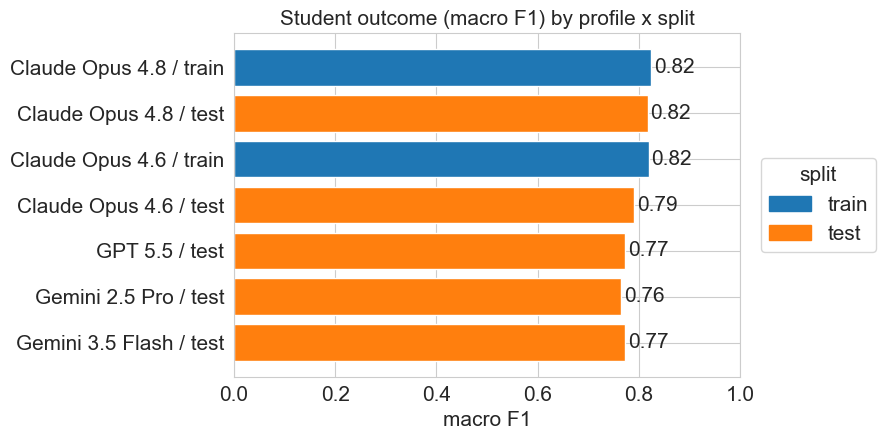

In [43]:
# --- Student outcome macro F1 ---
fig, ax = plt.subplots(figsize=(9, 4.5))
bar_by_run(ax, "student_outcome_f1", lim=(0, 1))
split_legend(ax, loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=15, title_fontsize=15)
# remap y tick labels from profile/split to model name (profile) + split
yticks = ax.get_yticks()
yticklabels = []
for y in yticks:
    if 0 <= y < len(df):
        run = df.iloc[int(y)]["run"]
        profile, split = run.split(" / ")
        model_name = model_map.get(profile, profile)
        yticklabels.append(f"{model_name} / {split}")
    else:
        yticklabels.append("")
ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels, fontsize=15)
ax.set_title("Student outcome (macro F1) by profile x split", fontsize=15)
ax.set_xlabel("macro F1", fontsize=15)
ax.tick_params(axis="x", labelsize=15)
fig.tight_layout()
plt.show()

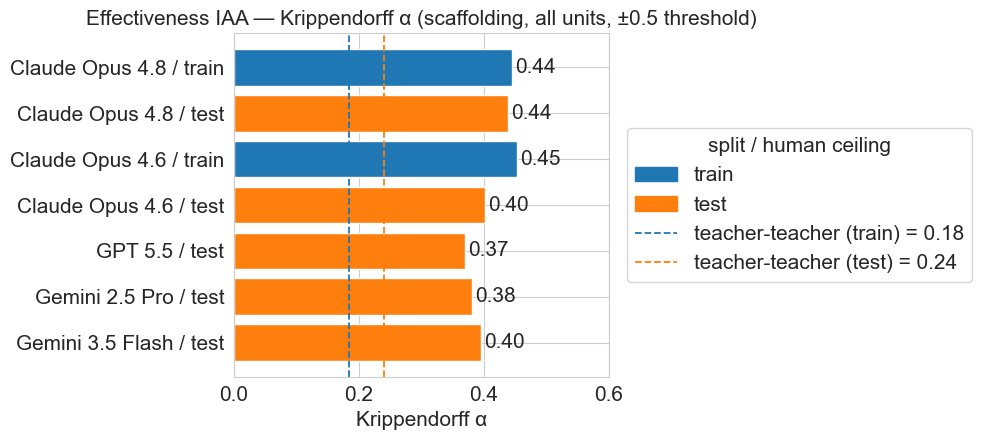

In [44]:
# --- Effectiveness IAA (Krippendorff alpha) @ +/-0.5 threshold, scaffolding, all units ---
fig, ax = plt.subplots(figsize=(10, 4.5))
bar_by_run(ax, "iaa_alpha", lim=(0, max(0.6, float(df["iaa_alpha"].max()) * 1.2)))

# Human-human agreement ceiling depends only on the split (same ground truth),
# not the model profile -- draw one dashed reference line per split (vertical
# now that the bars are horizontal).
ceil = df.groupby("split", observed=True)["human_ceiling_alpha"].mean()
ceil_handles = []
for sp in SPLIT_ORDER:
    val = ceil.get(sp)
    if pd.notna(val):
        line = ax.axvline(val, ls="--", lw=1.3, color=SPLIT_PALETTE[sp],
                          label=f"teacher-teacher ({sp}) = {val:.2f}")
        ceil_handles.append(line)

split_handles = [mpatches.Patch(color=SPLIT_PALETTE[s], label=s) for s in SPLIT_ORDER]
ax.legend(handles=split_handles + ceil_handles, fontsize=15, title="split / human ceiling", title_fontsize=15,
          loc="center left", bbox_to_anchor=(1.02, 0.5))
# remap y tick labels from profile/split to model name (profile) + split
yticks = ax.get_yticks()
yticklabels = []
for y in yticks:
    if 0 <= y < len(df):
        run = df.iloc[int(y)]["run"]
        profile, split = run.split(" / ")
        model_name = model_map.get(profile, profile)
        yticklabels.append(f"{model_name} / {split}")
    else:
        yticklabels.append("")
ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels, fontsize=15)
ax.set_title("Effectiveness IAA — Krippendorff α (scaffolding, all units, ±0.5 threshold)",
             fontsize=15)
ax.set_xlabel("Krippendorff α", fontsize=15)
ax.tick_params(axis="x", labelsize=15)
fig.tight_layout()
plt.show()

In [6]:
# Tidy summary: one row per run, all four metrics side by side
summary = df[[
    "profile", "split",
    "action_dir_scaffolding_f1", "action_dir_rigor_f1",
    "student_outcome_f1", "iaa_alpha", "iaa_n_units", "human_ceiling_alpha",
]].copy()
summary

,profile,split,action_dir_scaffolding_f1,action_dir_rigor_f1,student_outcome_f1,iaa_alpha,iaa_n_units,human_ceiling_alpha
0,anthropic,train,0.9310,0.6537,0.8240,0.4449,866,0.1848
1,anthropic,test,0.9338,0.6349,0.8175,0.4389,670,0.2403
2,anthropic46,train,0.9335,0.6255,0.8195,0.4533,866,0.1848
3,anthropic46,test,0.9440,0.6157,0.7905,0.4016,670,0.2403
4,openai,test,0.8968,0.5958,0.7734,0.3701,670,0.2403
5,gemini_25_pro,test,0.9494,0.5517,0.7649,0.3809,670,0.2403
6,gemini_35_flash,test,0.9388,0.6139,0.7733,0.3952,670,0.2403
